## Introduction ##


The datasets contains transactions made by credit cards in September 2013 by european cardholders. This dataset presents transactions that occurred in two days, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation.

Due to confidentiality issues, there are not provided the original features and more background information about the data.

- Features V1, V2, ... V28 are the principal components obtained with PCA;
- The only features which have not been transformed with PCA are Time and Amount. Feature Time contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature Amount is the transaction Amount, this feature can be used for example-dependant cost-senstive learning.
- Feature Class is the response variable and it takes value 1 in case of fraud and 0 otherwise.

## Load Packages ##

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.figure_factory as ff
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import AdaBoostClassifier


## Read the data ##

In [2]:
df = pd.read_csv(f"C:/Users/pavan/Desktop/Credit Fraud Detection/creditcard.csv")

## Check the data ## 


In [3]:
print("Credit Card Fraud Detection data -  rows:",df.shape[0]," columns:", df.shape[1])

Credit Card Fraud Detection data -  rows: 284807  columns: 31


## Glimpse the data ##

--> We start by looking to the data features (first 10 rows)



In [4]:
df.head(10)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [5]:
df.tail(10)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284797,172782.0,-0.241923,0.712247,0.399806,-0.463406,0.244531,-1.343668,0.929369,-0.206210,0.106234,...,-0.228876,-0.514376,0.279598,0.371441,-0.559238,0.113144,0.131507,0.081265,5.49,0
284798,172782.0,0.219529,0.881246,-0.635891,0.960928,-0.152971,-1.014307,0.427126,0.121340,-0.285670,...,0.099936,0.337120,0.251791,0.057688,-1.508368,0.144023,0.181205,0.215243,24.05,0
284799,172783.0,-1.775135,-0.004235,1.189786,0.331096,1.196063,5.519980,-1.518185,2.080825,1.159498,...,0.103302,0.654850,-0.348929,0.745323,0.704545,-0.127579,0.454379,0.130308,79.99,0
284800,172784.0,2.039560,-0.175233,-1.196825,0.234580,-0.008713,-0.726571,0.017050,-0.118228,0.435402,...,-0.268048,-0.717211,0.297930,-0.359769,-0.315610,0.201114,-0.080826,-0.075071,2.68,0
284801,172785.0,0.120316,0.931005,-0.546012,-0.745097,1.130314,-0.235973,0.812722,0.115093,-0.204064,...,-0.314205,-0.808520,0.050343,0.102800,-0.435870,0.124079,0.217940,0.068803,2.69,0
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Looking to the Time feature, we can confirm that the data contains 284,807 transactions, during 2 consecutive days (or 172792 seconds).

In [8]:
df.isnull().sum()


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [10]:
df.value_counts('Class')

Class
0    284315
1       492
Name: count, dtype: int64

## Check Missing Data ## 

- Let's check if their any missing data.

In [11]:
total = df.isnull().sum()
percent = (df.isnull().sum() / len(df)) * 100
result = pd.concat([total, percent], axis=1, keys=['Total', 'Percent']).T

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

display(result)



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Total,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Percent,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


- There is no missing data in the entire dataset.

## Data unbalance ##

- Let's check data unbalance with respect with target value, i.e. Class.

C:\Users\pavan\AppData\Local\Temp\ipykernel_37400\498691666.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Class", palette=["green", "red"])


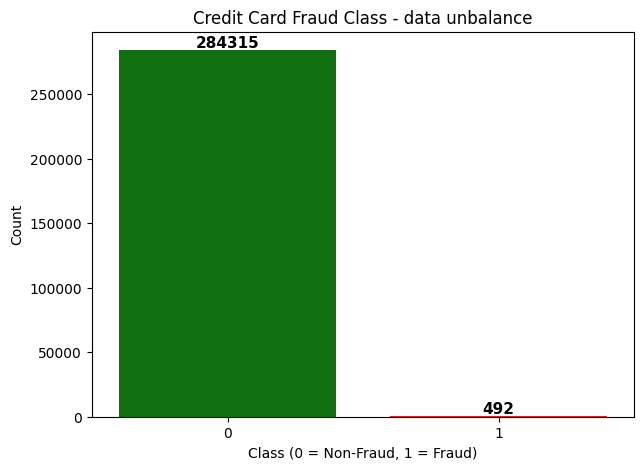

In [12]:
plt.figure(figsize=(7,5)) # Defines the size of the plot so it appears clear and readable.

class_count = df["Class"].value_counts().sort_index()


ax = sns.countplot(data=df, x="Class", palette=["green", "red"])

plt.title('Credit Card Fraud Class - data unbalance')  # Makes the plot easy to understand by adding a title and axis labels.
plt.xlabel("Class (0 = Non-Fraud, 1 = Fraud)")
plt.ylabel("Count")

# Add text above bars
for i, v in enumerate(class_count):
    ax.text(i, v + 2000, str(v), ha='center', fontsize=11, fontweight='bold')

plt.show()

- Only 492 or (0.172%) of transaction are fraudulent.That means the data is highly unbalanced with respect with target variable "class".

# Data Exploration (EDA) #

## Transactions Over Time ##

### 1. Create Hour Column ##

In [13]:
# Convert Time (seconds) into Hour of the day (0–47 for 2 days)

df['Hour'] = (df['Time'] // 3600).astype(int)

In [14]:
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,47
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,47
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,47
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,47


### 2. Aggregate Per Hour ##

In [15]:
tmp = df.groupby(['Hour', 'Class'])['Amount'].agg( ['min', 'max', 'count', 'sum', 'mean', 'median', 'var'] ).reset_index() 
tmp.columns = ['Hour', 'Class', 'Min', 'Max', 'Transactions', 'Sum', 'Mean', 'Median', 'Var']
tmp.head(10)

,Hour,Class,Min,Max,Transactions,Sum,Mean,Median,Var
0,0,0,0.0,7712.43,3961,256572.87,64.774772,12.990,45615.821201
1,0,1,0.0,529.00,2,529.00,264.500000,264.500,139920.500000
2,1,0,0.0,1769.69,2215,145806.76,65.826980,22.820,20053.615770
3,1,1,59.0,239.93,2,298.93,149.465000,149.465,16367.832450
4,2,0,0.0,4002.88,1555,106989.39,68.803466,17.900,45355.430437
5,2,1,1.0,1809.68,21,1829.78,87.132381,1.000,155776.441219
6,3,0,0.0,1903.26,1808,94086.79,52.039154,15.950,16741.786661
7,3,1,0.0,179.66,13,220.05,16.926923,1.000,2457.208190
8,4,0,0.0,2126.13,1076,79050.36,73.466877,15.950,24416.863654
9,4,1,1.0,766.36,6,790.26,131.710000,3.860,96679.482040


### 3. Transactions by Hour (Fraud vs Non-Fraud) ##

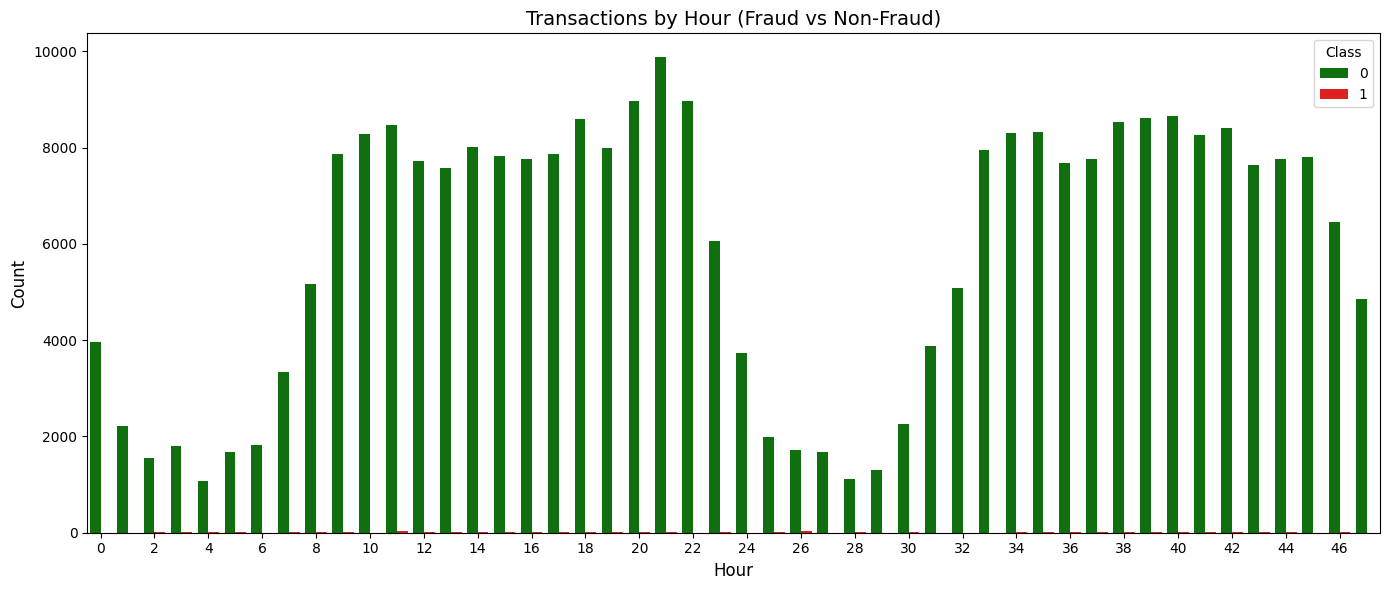

In [16]:
plt.figure(figsize=(14,6))
sns.countplot(data=df, x='Hour', hue='Class', palette=['green','red'])

plt.title("Transactions by Hour (Fraud vs Non-Fraud)", fontsize=14)
plt.xlabel("Hour", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Clean x-axis labels
plt.xticks(ticks=range(0, 48, 2))   # Show every 2 hours
plt.tight_layout()
plt.show()


## Interpretation :

Most genuine transactions occur during daytime.
Fraud transactions appear in low-traffic hours and scattered across the timeline.

## 3. Fraud Rate by Hour ##

- (Fraud Rate = frauds / total transactions)

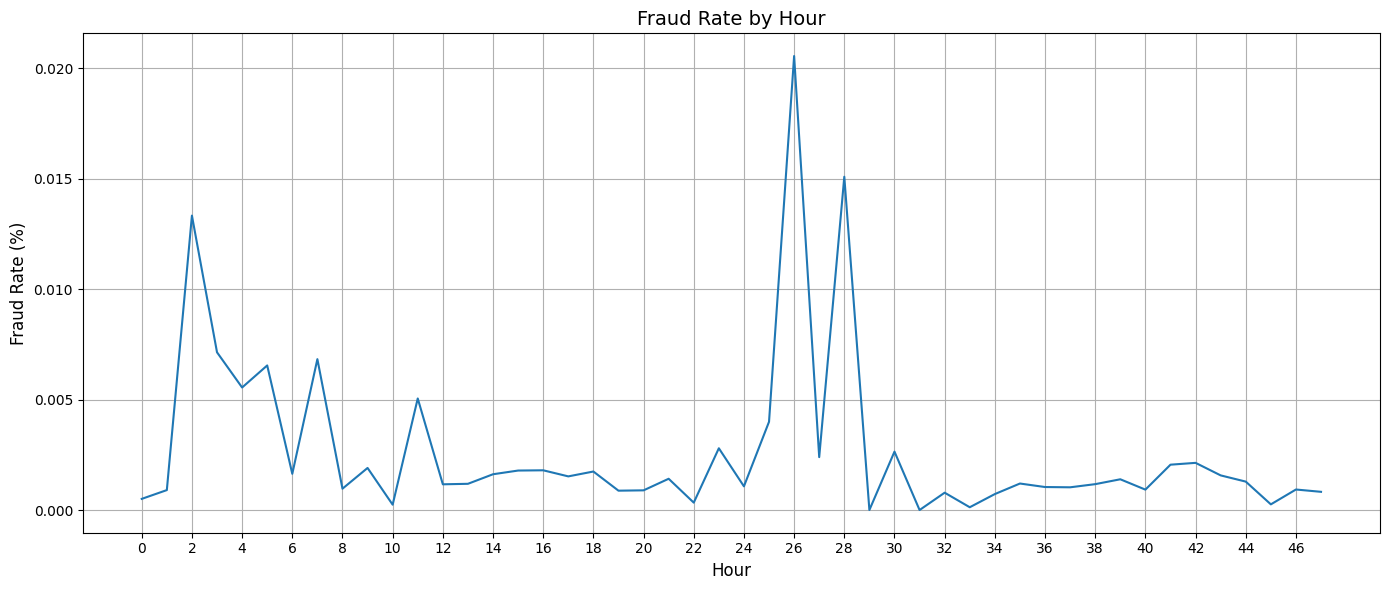

In [17]:
fraud_rate = df.groupby('Hour')['Class'].mean()  # Mean gives fraud % by hour

plt.figure(figsize=(14,6))
plt.plot(fraud_rate.index, fraud_rate.values)

plt.title("Fraud Rate by Hour", fontsize=14)
plt.xlabel("Hour", fontsize=12)
plt.ylabel("Fraud Rate (%)", fontsize=12)

plt.grid(True)
plt.xticks(ticks=range(0, 48, 2))  
plt.tight_layout()
plt.show()


## Interpretation:

Fraud rate spikes at specific hours, meaning fraudsters prefer certain windows of time where monitoring is low.

## 4. Average Transaction Amount by Hour (Fraud vs Non-Fraud) ##

<Figure size 1400x600 with 0 Axes>

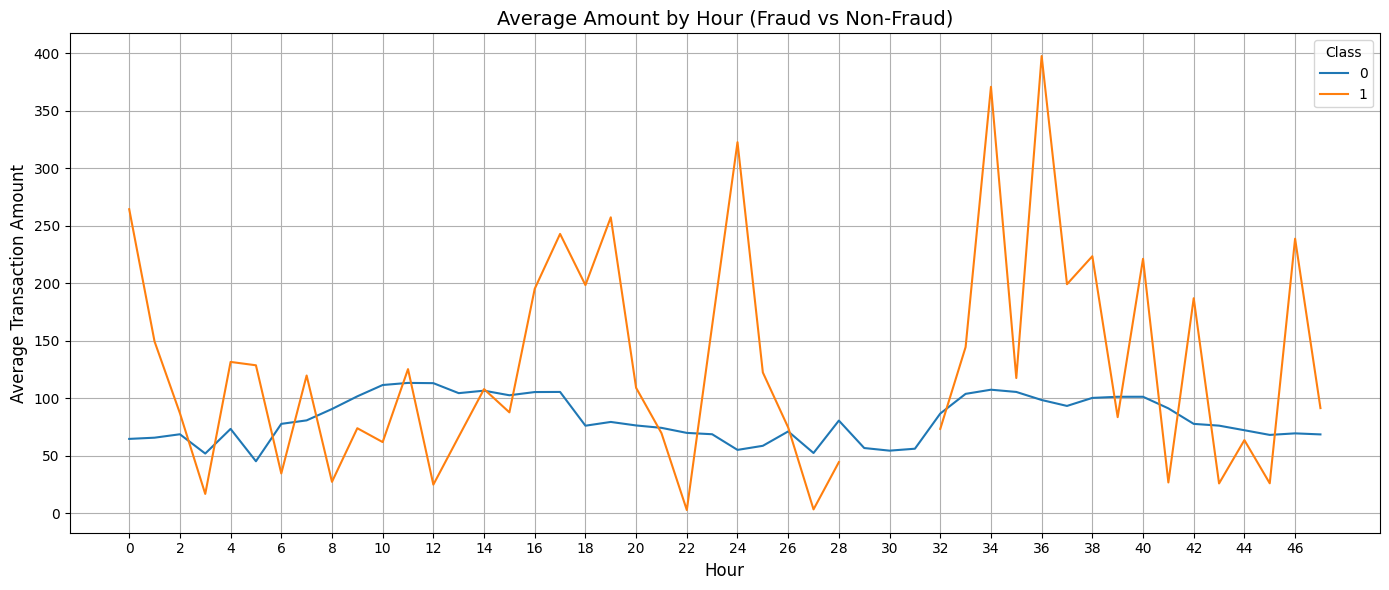

In [18]:
# First Aggregate Data to get Average Amount by Hour and Class

hourly_avg = df.groupby(['Hour', 'Class'])['Amount'].mean().unstack()

plt.figure(figsize=(14,6))
hourly_avg.plot(figsize=(14,6))

plt.title("Average Amount by Hour (Fraud vs Non-Fraud)", fontsize=14)
plt.xlabel("Hour", fontsize=12)
plt.ylabel("Average Transaction Amount", fontsize=12)

plt.xticks(ticks=range(0, 48, 2))
plt.grid(True)
plt.tight_layout()
plt.show()



## Interpretation:

Fraud amounts are more volatile than normal amounts.
Some hours show unusually high average fraud amounts, indicating risk periods.

# Transactions in Amount #

## 1. Distribution of Transaction Amounts ##

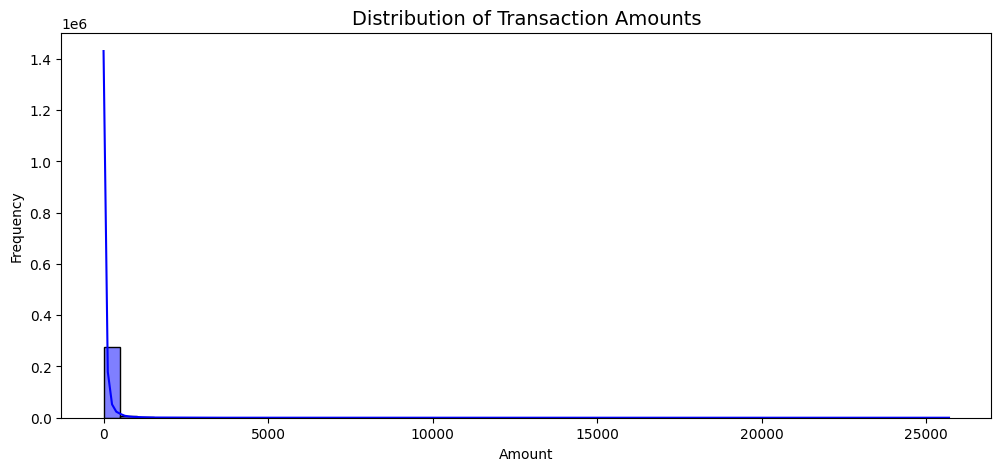

In [19]:
plt.figure(figsize=(12,5))
sns.histplot(df['Amount'], bins=50, kde=True, color='blue')
plt.title("Distribution of Transaction Amounts", fontsize=14)
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()


## Interpretation:

Most transactions are very small (₹0–₹100).
A few large-value transactions create a long right-tail.
The data is highly skewed, common in financial datasets.

## 2. Amount Distribution: Fraud vs Non-Fraud ##

C:\Users\pavan\AppData\Local\Temp\ipykernel_37400\2459459598.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Class', y='Amount', data=df, palette=['green','red'])


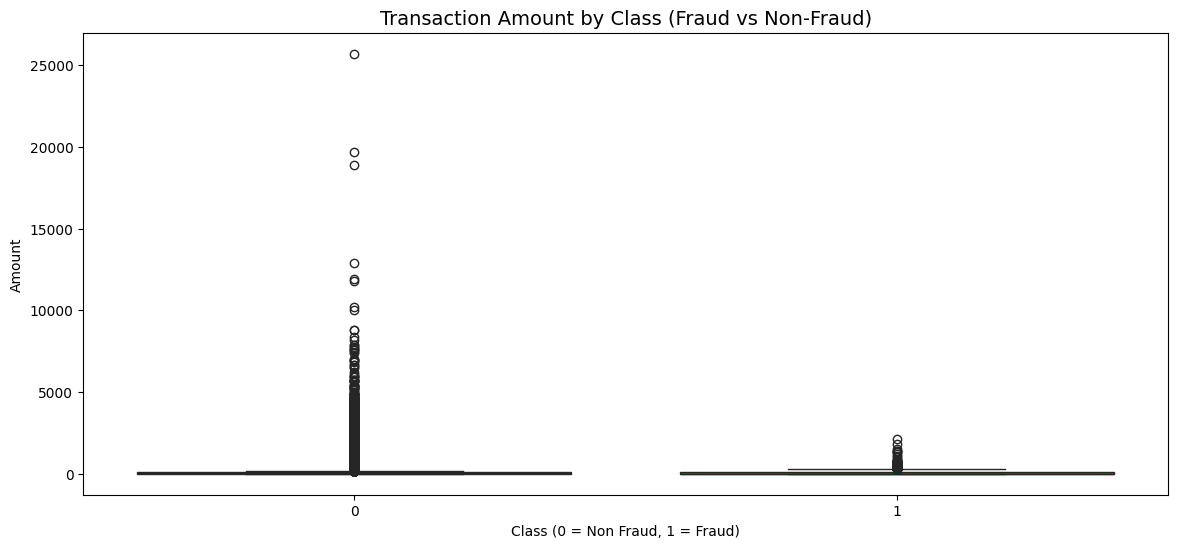

In [20]:
plt.figure(figsize=(14,6))
sns.boxplot(x='Class', y='Amount', data=df, palette=['green','red'])

plt.title("Transaction Amount by Class (Fraud vs Non-Fraud)", fontsize=14)
plt.xlabel("Class (0 = Non Fraud, 1 = Fraud)")
plt.ylabel("Amount")
plt.show()


## Interpretation:

Normal transactions have small and consistent amounts.
Fraud transactions show higher variation and multiple large outliers.
Fraudsters often attempt high-value transactions.

## 3. Log-Scaled Amount Distribution ##

- Fraud amounts are often skewed. Log scale helps.
- Log transform reduces skewness.

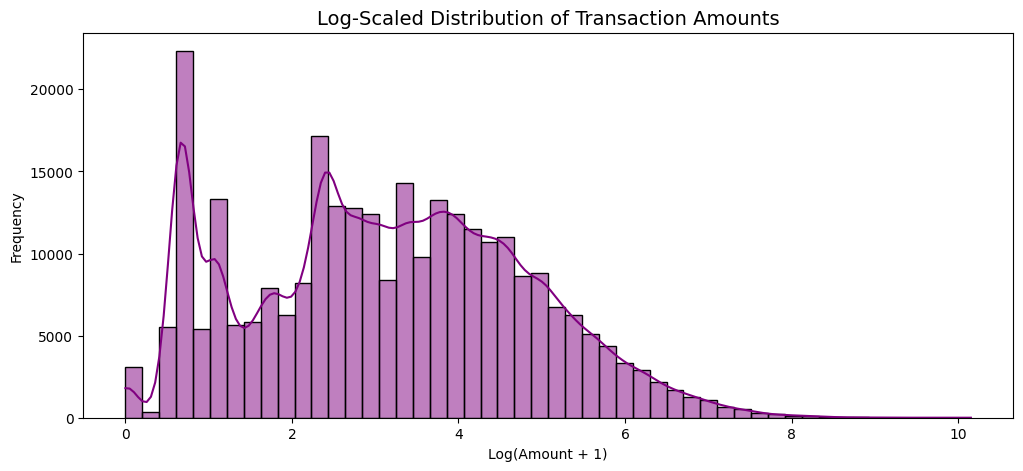

In [21]:
plt.figure(figsize=(12,5))
sns.histplot(np.log1p(df['Amount']), bins=50, kde=True, color='purple')
plt.title("Log-Scaled Distribution of Transaction Amounts", fontsize=14)
plt.xlabel("Log(Amount + 1)")
plt.ylabel("Frequency")
plt.show()


## Interpretation:

Log transformation makes the distribution smoother
→ Helps machine learning models learn better.
→ Reduces the effect of extreme values.

## 4. Comparing Average Amounts (Fraud vs Non-Fraud) ##


In [22]:
# Compute Average 

fraud_avg = df.groupby("Class")["Amount"].mean()
fraud_avg

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

C:\Users\pavan\AppData\Local\Temp\ipykernel_37400\1447529131.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_avg.index, y=fraud_avg.values, palette=["green","red"])


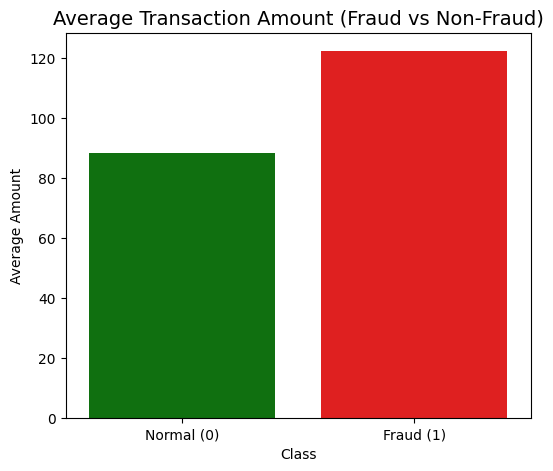

In [23]:
plt.figure(figsize=(6,5))
sns.barplot(x=fraud_avg.index, y=fraud_avg.values, palette=["green","red"])

plt.title("Average Transaction Amount (Fraud vs Non-Fraud)", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Average Amount")
plt.xticks([0,1], ["Normal (0)", "Fraud (1)"])
plt.show()


## Interpretation:

- Fraud average amount ≈ Higher
- Normal average amount ≈ Lower
- Fraudsters try to maximize financial gain, leading to higher average value.

## 5. Kernel Density Estimate (KDE) — Fraud vs Non-Fraud Amounts ##

C:\Users\pavan\AppData\Local\Temp\ipykernel_37400\2680773151.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Class']==0]['Amount'], shade=True, label='Normal', color='green')
C:\Users\pavan\AppData\Local\Temp\ipykernel_37400\2680773151.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['Class']==1]['Amount'], shade=True, label='Fraud', color='red')


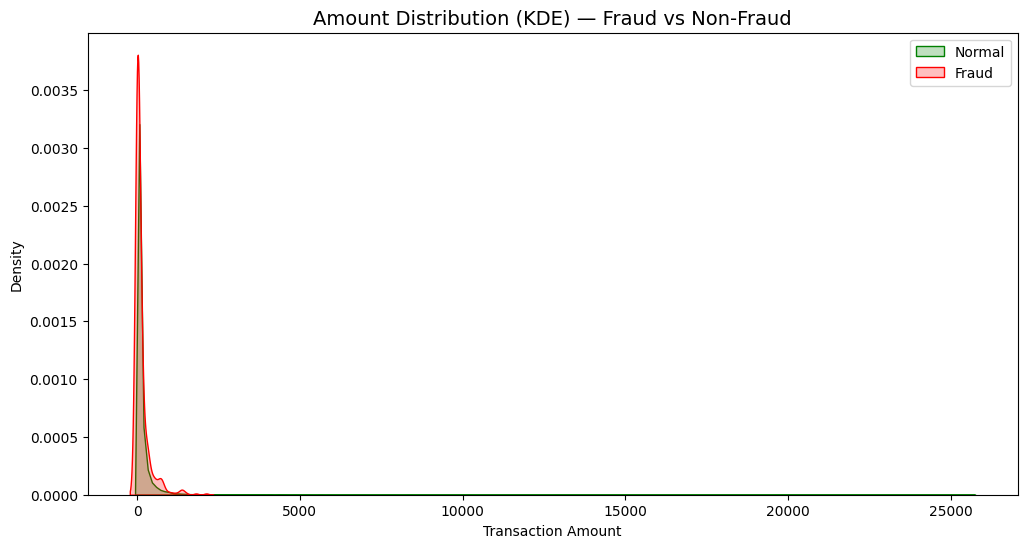

In [24]:
plt.figure(figsize=(12,6))
sns.kdeplot(df[df['Class']==0]['Amount'], shade=True, label='Normal', color='green')
sns.kdeplot(df[df['Class']==1]['Amount'], shade=True, label='Fraud', color='red')
plt.title("Amount Distribution (KDE) — Fraud vs Non-Fraud", fontsize=14)
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.legend()
plt.show()


## Interpretation:

- Normal customers show a peak at small amounts.
- Fraud amounts are spread out and inconsistent.
- Fraud pattern is irregular, making amount a strong fraud indicator.


## Feautures Correlation 

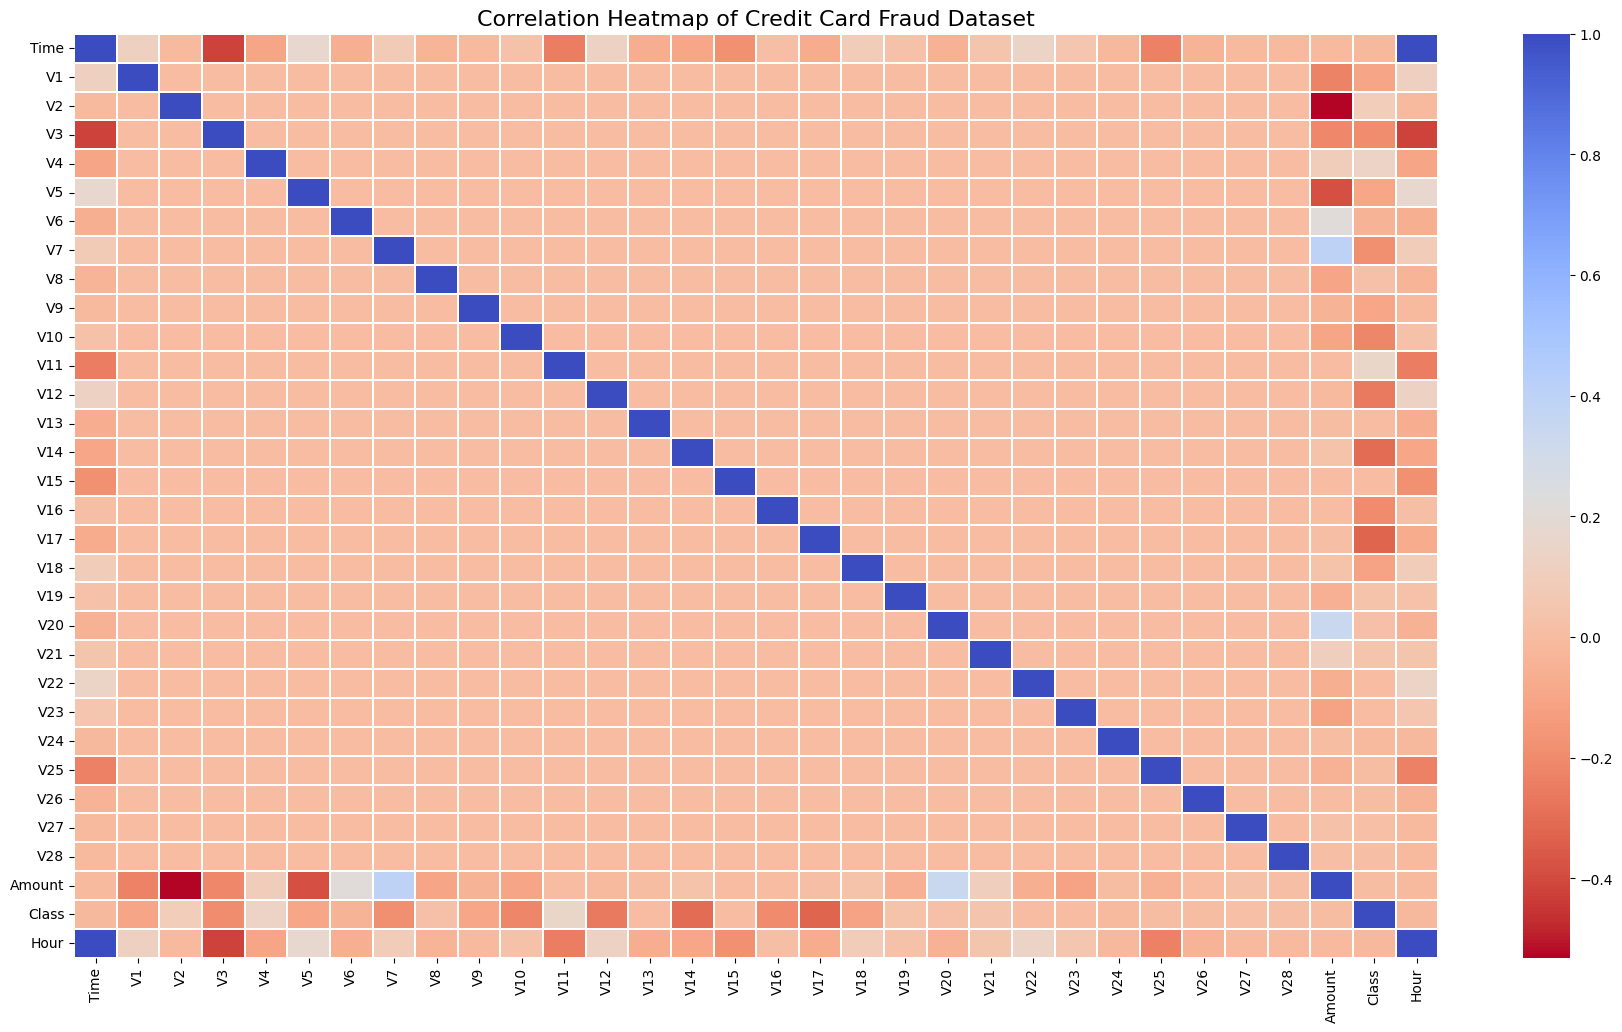

In [25]:
# Compute Correlation Heatmap 
corr = df.corr()

# plot the heatmap 
plt.figure(figsize=(22,12))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm_r",   # shows positive & negative clearly
    annot=False,         # avoid clutter
    linewidths=0.3
)

plt.title("Correlation Heatmap of Credit Card Fraud Dataset", fontsize=16)
plt.show()

## Interpretation :

- The correlation heatmap shows that most PCA-transformed features have very low correlation with each other and with the target variable, which is expected due to the nature of PCA.

- A few components such as V17, V14, V12, and V10 show relatively stronger correlations with fraud (positive or negative), meaning they carry important fraud-related patterns.

- Time, Hour, and Amount show very low correlation with the target, but distribution-based EDA reveals that Amount and Hour still influence fraud behavior even if Pearson correlation is low.

C:\Users\pavan\AppData\Local\Temp\ipykernel_37400\1403769164.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_target.values, y=corr_target.index, palette="viridis")


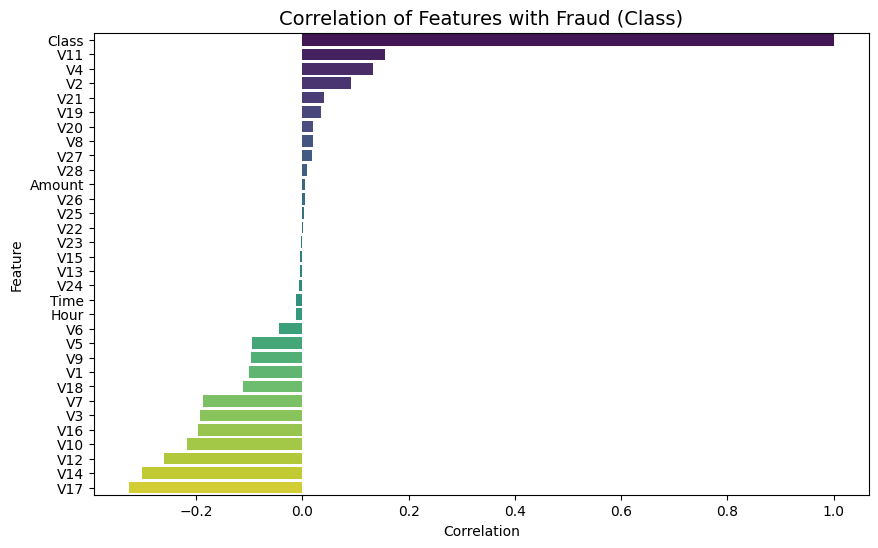

In [26]:
# Correlation of Features with Target Variable 'Class'

plt.figure(figsize=(10,6))
corr_target = corr["Class"].sort_values(ascending=False)

sns.barplot(x=corr_target.values, y=corr_target.index, palette="viridis")

plt.title("Correlation of Features with Fraud (Class)", fontsize=14)
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.show()



# Predictive Models 

In [27]:
from sklearn.preprocessing import RobustScaler

# Step 1: Drop unneeded time columns
df_model = df.drop(['Time', 'Hour'], axis=1)

# Step 2: Define predictors and target
X = df_model.drop('Class', axis=1)
y = df_model['Class']

# Step 3: Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3.1: Scale the 'Amount' column using RobustScaler
scaler = RobustScaler()
X_train['Amount'] = scaler.fit_transform(X_train[['Amount']])
X_test['Amount'] = scaler.transform(X_test[['Amount']])

## STEP 4 - Model Evaluation Function

In [28]:
def evaluate(model, X_test, y_test):
    y_pred = model.predict(X_test)
    print('classification_report:\n', classification_report(y_test, y_pred))
    print('confusion_matrix:\n', confusion_matrix(y_test, y_pred))
    print('roc_auc_score:', roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))
    print("-"*60)

## STEP 5 - Train All Requested Models

In [29]:
## STEP 5 - Train All Requested Models

# Calculate imbalance ratio for XGBoost & LightGBM
ratio = (len(y_train) - sum(y_train)) / sum(y_train)

# Initialize models with class balancing turned on
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=100, 
        class_weight='balanced', 
        random_state=42, 
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100, 
        scale_pos_weight=ratio, 
        random_state=42, 
        eval_metric='logloss'
    ),
    "CatBoost": CatBoostClassifier(
        iterations=100, 
        auto_class_weights='Balanced', 
        random_state=42, 
        verbose=0
    ),
    "AdaBoost": AdaBoostClassifier(
        n_estimators=100, 
        random_state=42
    )
}

# Run loop to train and evaluate each model
for name, model in models.items():
    print(f"==================== Training {name} ====================")
    model.fit(X_train, y_train)
    evaluate(model, X_test, y_test)
best_model = models["XGBoost"]

==================== Training Random Forest ====================
classification_report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

confusion_matrix:
 [[56861     3]
 [   24    74]]
roc_auc_score: 0.9580130501131234
------------------------------------------------------------
==================== Training XGBoost ====================
classification_report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.85      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

confusion_matrix:
 [[56853   

In [30]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score

# 1. Store your results directly from your training output
results_data = [
    {'Model': 'XGBoost', 'Precision (Fraud)': 0.8800, 'Recall (Fraud)': 0.8500, 'F1-Score (Fraud)': 0.8600, 'ROC-AUC': 0.9691},
    {'Model': 'Random Forest', 'Precision (Fraud)': 0.9600, 'Recall (Fraud)': 0.7600, 'F1-Score (Fraud)': 0.8500, 'ROC-AUC': 0.9580},
    {'Model': 'CatBoost', 'Precision (Fraud)': 0.6600, 'Recall (Fraud)': 0.8600, 'F1-Score (Fraud)': 0.7400, 'ROC-AUC': 0.9667},
    {'Model': 'AdaBoost', 'Precision (Fraud)': 0.7100, 'Recall (Fraud)': 0.7300, 'F1-Score (Fraud)': 0.7200, 'ROC-AUC': 0.9792}
]

# 2. Build DataFrame
comparison_df = pd.DataFrame(results_data).sort_values(by='F1-Score (Fraud)', ascending=False)
display(comparison_df)

,Model,Precision (Fraud),Recall (Fraud),F1-Score (Fraud),ROC-AUC
0,XGBoost,0.88,0.85,0.86,0.9691
1,Random Forest,0.96,0.76,0.85,0.9580
2,CatBoost,0.66,0.86,0.74,0.9667
3,AdaBoost,0.71,0.73,0.72,0.9792


## Step 7: Threshold Tuning (XGBoost)

In [31]:
from sklearn.metrics import precision_recall_curve, f1_score

# Predict probabilities
y_probs = best_model.predict_proba(X_test)[:,1]

# Get thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    pred = (y_probs >= t).astype(int)
    score = f1_score(y_test, pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Best F1:", best_f1)

# Final Prediction
y_pred = (y_probs >= best_threshold).astype(int)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Best Threshold: 0.9658929
Best F1: 0.8743169398907104
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

[[56859     5]
 [   18    80]]


In [32]:
import shap
import matplotlib.pyplot as plt

# Initialize SHAP Explainer
explainer = shap.TreeExplainer(best_model)

# Sample 1000 transactions for faster explanation
X_test_sample = X_test.sample(n=1000, random_state=42)

# Compute SHAP values
shap_values = explainer(X_test_sample)

c:\Users\pavan\Desktop\Credit Fraud Detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


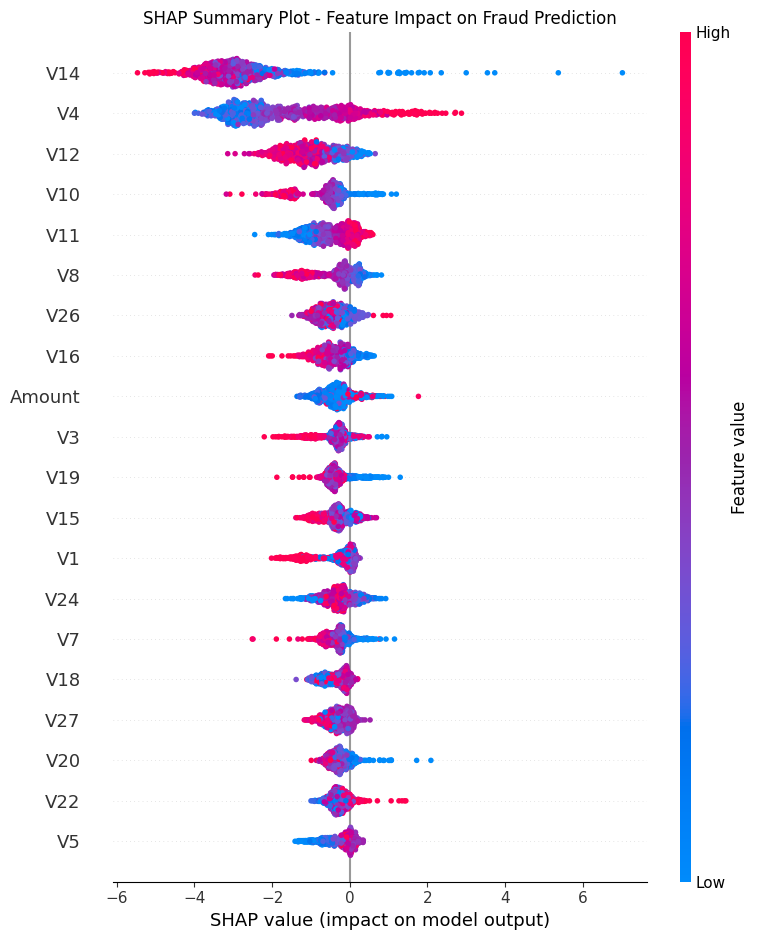

In [33]:
# 1. SHAP Summary Plot

plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    X_test_sample,
    show=False
)

plt.title("SHAP Summary Plot - Feature Impact on Fraud Prediction")
plt.tight_layout()
plt.show()

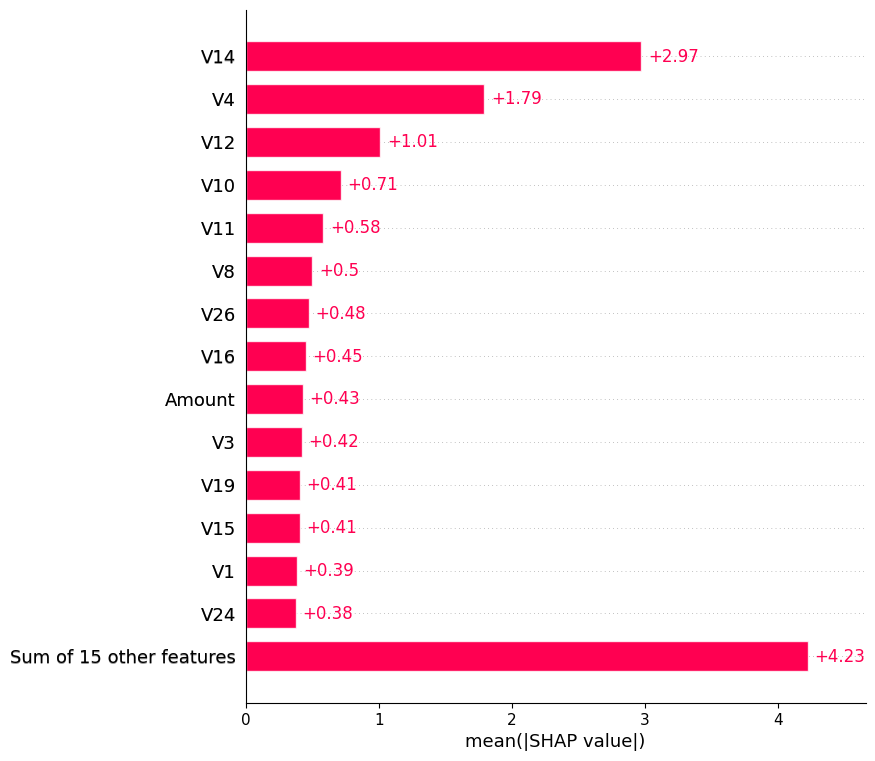

In [34]:
# 2. SHAP Feature Importance Bar Plot

plt.figure(figsize=(10,6))
shap.plots.bar(
    shap_values,
    max_display=15
)

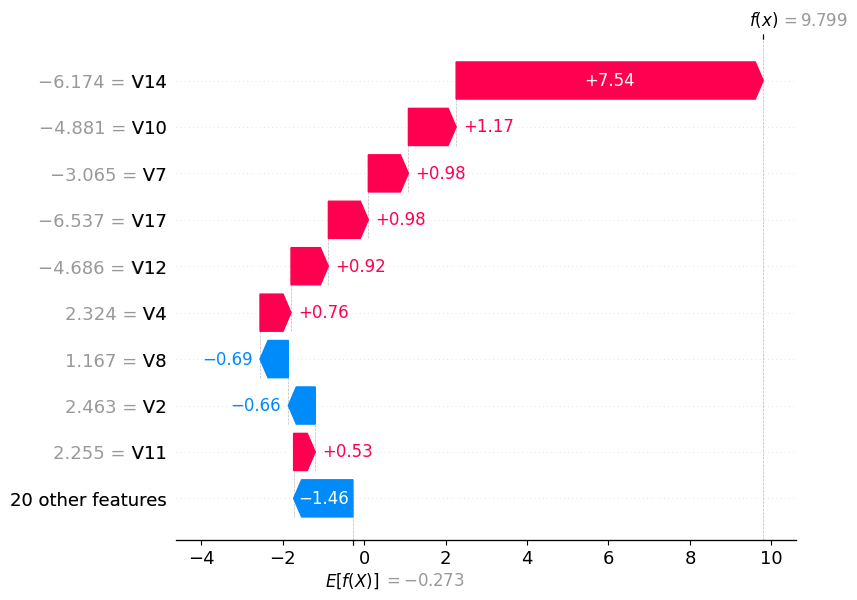

In [35]:
# 3. SHAP Waterfall Plot

fraud_index = y_test[y_test == 1].index[0]

sample = X_test.loc[[fraud_index]]

sample_shap = explainer(sample)

shap.plots.waterfall(sample_shap[0])

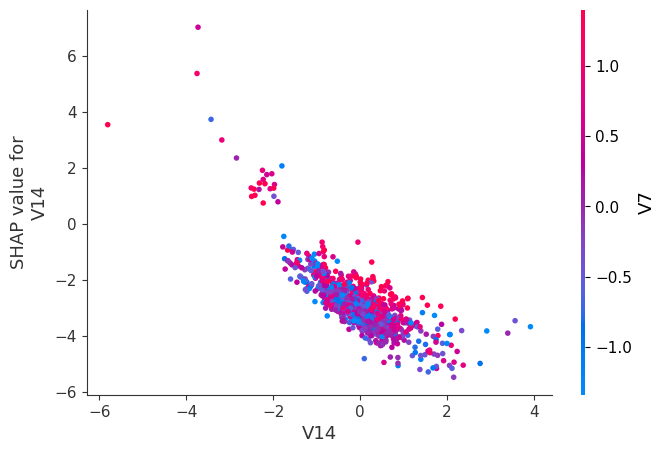

In [36]:
# 4. SHAP Dependence Plot


shap.dependence_plot(
    "V14",
    shap_values.values,
    X_test_sample
)

## Step 9 – Save the Model, Scaler & Threshold

In [37]:
import joblib

joblib.dump(best_model, "xgb_fraud_model.pkl")
joblib.dump(scaler, "robust_scaler.pkl")
joblib.dump(best_threshold, "threshold.pkl")


['threshold.pkl']

In [38]:
import os

print(os.listdir())

['.venv', 'app.py', 'catboost_info', 'creditcard.csv', 'main.ipynb', 'robust_scaler.pkl', 'streamlit_app.py', 'threshold.pkl', 'xgb_fraud_model.pkl', '__pycache__']


In [1]:
import pandas as pd
df = pd.read_csv("creditcard.csv")
sample = pd.concat([
    df[df.Class == 0].sample(20, random_state=1),
    df[df.Class == 1].sample(5, random_state=1)
])
sample.to_csv("batch_test_sample.csv", index=False)